# LAB-Audio-03 Assignment

### 2021041017 Kim Gyu Hyeon (김규현)

---

In [ ]:
# !pip install deep_phonemizer

In [ ]:
import torch
import torchaudio
import IPython
import matplotlib.pyplot as plt

torch.random.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(torch.__version__)
print(torchaudio.__version__)
print(device)

2.8.0+cu126
2.8.0+cu126
cuda


<br/>

## Text Processing

In [ ]:
symbols = "_-!'(),.:;? abcdefghijklmnopqrstuvwxyz"
look_up = {s: i for i, s in enumerate(symbols)}
symbols = set(symbols)


def text_to_sequence(text):
    text = text.lower()
    return [look_up[s] for s in text if s in symbols]


text = "Hello. My name is Gyu Hyeon Kim, a Junior in the Department of Computer Science at Chungbuk National University. I am honored to have the opportunity to learn PyTorch through this Artificial Intelligence course."
print(text_to_sequence(text))

[19, 16, 23, 23, 26, 7, 11, 24, 36, 11, 25, 12, 24, 16, 11, 20, 30, 11, 18, 36, 32, 11, 19, 36, 16, 26, 25, 11, 22, 20, 24, 6, 11, 12, 11, 21, 32, 25, 20, 26, 29, 11, 20, 25, 11, 31, 19, 16, 11, 15, 16, 27, 12, 29, 31, 24, 16, 25, 31, 11, 26, 17, 11, 14, 26, 24, 27, 32, 31, 16, 29, 11, 30, 14, 20, 16, 25, 14, 16, 11, 12, 31, 11, 14, 19, 32, 25, 18, 13, 32, 22, 11, 25, 12, 31, 20, 26, 25, 12, 23, 11, 32, 25, 20, 33, 16, 29, 30, 20, 31, 36, 7, 11, 20, 11, 12, 24, 11, 19, 26, 25, 26, 29, 16, 15, 11, 31, 26, 11, 19, 12, 33, 16, 11, 31, 19, 16, 11, 26, 27, 27, 26, 29, 31, 32, 25, 20, 31, 36, 11, 31, 26, 11, 23, 16, 12, 29, 25, 11, 27, 36, 31, 26, 29, 14, 19, 11, 31, 19, 29, 26, 32, 18, 19, 11, 31, 19, 20, 30, 11, 12, 29, 31, 20, 17, 20, 14, 20, 12, 23, 11, 20, 25, 31, 16, 23, 23, 20, 18, 16, 25, 14, 16, 11, 14, 26, 32, 29, 30, 16, 7]


In [ ]:
processor = torchaudio.pipelines.TACOTRON2_WAVERNN_CHAR_LJSPEECH.get_text_processor()

text = "Hello. My name is Gyu Hyeon Kim, a Junior in the Department of Computer Science at Chungbuk National University. I am honored to have the opportunity to learn PyTorch through this Artificial Intelligence course."
processed, lengths = processor(text)

print(processed)
print(lengths)

tensor([[19, 16, 23, 23, 26,  7, 11, 24, 36, 11, 25, 12, 24, 16, 11, 20, 30, 11,
         18, 36, 32, 11, 19, 36, 16, 26, 25, 11, 22, 20, 24,  6, 11, 12, 11, 21,
         32, 25, 20, 26, 29, 11, 20, 25, 11, 31, 19, 16, 11, 15, 16, 27, 12, 29,
         31, 24, 16, 25, 31, 11, 26, 17, 11, 14, 26, 24, 27, 32, 31, 16, 29, 11,
         30, 14, 20, 16, 25, 14, 16, 11, 12, 31, 11, 14, 19, 32, 25, 18, 13, 32,
         22, 11, 25, 12, 31, 20, 26, 25, 12, 23, 11, 32, 25, 20, 33, 16, 29, 30,
         20, 31, 36,  7, 11, 20, 11, 12, 24, 11, 19, 26, 25, 26, 29, 16, 15, 11,
         31, 26, 11, 19, 12, 33, 16, 11, 31, 19, 16, 11, 26, 27, 27, 26, 29, 31,
         32, 25, 20, 31, 36, 11, 31, 26, 11, 23, 16, 12, 29, 25, 11, 27, 36, 31,
         26, 29, 14, 19, 11, 31, 19, 29, 26, 32, 18, 19, 11, 31, 19, 20, 30, 11,
         12, 29, 31, 20, 17, 20, 14, 20, 12, 23, 11, 20, 25, 31, 16, 23, 23, 20,
         18, 16, 25, 14, 16, 11, 14, 26, 32, 29, 30, 16,  7]])
tensor([211], dtype=torch.int32)


In [ ]:
print([processor.tokens[i] for i in processed[0, : lengths[0]]])

['h', 'e', 'l', 'l', 'o', '.', ' ', 'm', 'y', ' ', 'n', 'a', 'm', 'e', ' ', 'i', 's', ' ', 'g', 'y', 'u', ' ', 'h', 'y', 'e', 'o', 'n', ' ', 'k', 'i', 'm', ',', ' ', 'a', ' ', 'j', 'u', 'n', 'i', 'o', 'r', ' ', 'i', 'n', ' ', 't', 'h', 'e', ' ', 'd', 'e', 'p', 'a', 'r', 't', 'm', 'e', 'n', 't', ' ', 'o', 'f', ' ', 'c', 'o', 'm', 'p', 'u', 't', 'e', 'r', ' ', 's', 'c', 'i', 'e', 'n', 'c', 'e', ' ', 'a', 't', ' ', 'c', 'h', 'u', 'n', 'g', 'b', 'u', 'k', ' ', 'n', 'a', 't', 'i', 'o', 'n', 'a', 'l', ' ', 'u', 'n', 'i', 'v', 'e', 'r', 's', 'i', 't', 'y', '.', ' ', 'i', ' ', 'a', 'm', ' ', 'h', 'o', 'n', 'o', 'r', 'e', 'd', ' ', 't', 'o', ' ', 'h', 'a', 'v', 'e', ' ', 't', 'h', 'e', ' ', 'o', 'p', 'p', 'o', 'r', 't', 'u', 'n', 'i', 't', 'y', ' ', 't', 'o', ' ', 'l', 'e', 'a', 'r', 'n', ' ', 'p', 'y', 't', 'o', 'r', 'c', 'h', ' ', 't', 'h', 'r', 'o', 'u', 'g', 'h', ' ', 't', 'h', 'i', 's', ' ', 'a', 'r', 't', 'i', 'f', 'i', 'c', 'i', 'a', 'l', ' ', 'i', 'n', 't', 'e', 'l', 'l', 'i', 'g', 'e',

In [ ]:
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH

processor = bundle.get_text_processor()

text = "Hello. My name is Gyu Hyeon Kim, a Junior in the Department of Computer Science at Chungbuk National University. I am honored to have the opportunity to learn PyTorch through this Artificial Intelligence course."
with torch.inference_mode():
    processed, lengths = processor(text)

print(processed)
print(lengths)

tensor([[54, 20, 65, 69,  7, 11, 66, 32, 11, 67, 48, 66, 11, 55, 94, 11, 53, 93,
         87, 11, 54, 32, 20, 67, 11, 64, 55, 66,  6, 11, 20, 11, 63, 87, 67, 93,
         44, 11, 55, 67, 11, 39, 20, 11, 38, 55, 77, 12, 78, 81, 66, 20, 67, 81,
         11, 20, 91, 11, 64, 20, 66, 77, 93, 87, 81, 44, 11, 79, 32, 20, 67, 79,
         11, 16, 81, 11, 37, 20, 68, 36, 20, 64, 11, 67, 16, 80, 20, 67, 20, 65,
         11, 93, 87, 67, 20, 91, 44, 79, 20, 81, 59,  7, 11, 32, 11, 16, 66, 11,
         12, 67, 44, 38, 11, 81, 20, 11, 54, 16, 91, 11, 39, 20, 11, 12, 77, 44,
         81, 87, 67, 20, 81, 59, 11, 81, 20, 11, 65, 44, 67, 11, 77, 32,  1, 81,
         24, 78, 37, 11, 82, 78, 87, 11, 39, 55, 79, 11, 12, 78, 81, 20, 52, 55,
         80, 20, 65, 11, 55, 67, 81, 40, 65, 20, 63, 20, 67, 79, 11, 64, 24, 78,
         79,  7]])
tensor([182], dtype=torch.int32)


In [ ]:
print([processor.tokens[i] for i in processed[0, : lengths[0]]])

['HH', 'AH', 'L', 'OW', '.', ' ', 'M', 'AY', ' ', 'N', 'EY', 'M', ' ', 'IH', 'Z', ' ', 'G', 'Y', 'UW', ' ', 'HH', 'AY', 'AH', 'N', ' ', 'K', 'IH', 'M', ',', ' ', 'AH', ' ', 'JH', 'UW', 'N', 'Y', 'ER', ' ', 'IH', 'N', ' ', 'DH', 'AH', ' ', 'D', 'IH', 'P', 'AA', 'R', 'T', 'M', 'AH', 'N', 'T', ' ', 'AH', 'V', ' ', 'K', 'AH', 'M', 'P', 'Y', 'UW', 'T', 'ER', ' ', 'S', 'AY', 'AH', 'N', 'S', ' ', 'AE', 'T', ' ', 'CH', 'AH', 'NG', 'B', 'AH', 'K', ' ', 'N', 'AE', 'SH', 'AH', 'N', 'AH', 'L', ' ', 'Y', 'UW', 'N', 'AH', 'V', 'ER', 'S', 'AH', 'T', 'IY', '.', ' ', 'AY', ' ', 'AE', 'M', ' ', 'AA', 'N', 'ER', 'D', ' ', 'T', 'AH', ' ', 'HH', 'AE', 'V', ' ', 'DH', 'AH', ' ', 'AA', 'P', 'ER', 'T', 'UW', 'N', 'AH', 'T', 'IY', ' ', 'T', 'AH', ' ', 'L', 'ER', 'N', ' ', 'P', 'AY', '-', 'T', 'AO', 'R', 'CH', ' ', 'TH', 'R', 'UW', ' ', 'DH', 'IH', 'S', ' ', 'AA', 'R', 'T', 'AH', 'F', 'IH', 'SH', 'AH', 'L', ' ', 'IH', 'N', 'T', 'EH', 'L', 'AH', 'JH', 'AH', 'N', 'S', ' ', 'K', 'AO', 'R', 'S', '.']


<br/>

## Spectrogram Generation

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


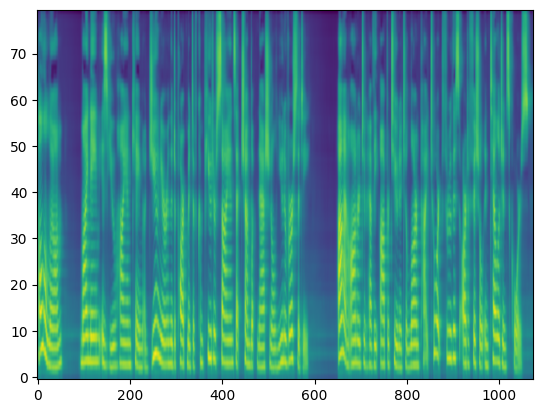

In [ ]:
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH
processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2().to(device)

text = "Hello. My name is Gyu Hyeon Kim, a Junior in the Department of Computer Science at Chungbuk National University. I am honored to have the opportunity to learn PyTorch through this Artificial Intelligence course."

with torch.inference_mode():
    processed, lengths = processor(text)
    processed = processed.to(device)
    lengths = lengths.to(device)
    spec, _, _ = tacotron2.infer(processed, lengths)


_ = plt.imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")

torch.Size([80, 1012])
torch.Size([80, 1063])
torch.Size([80, 1063])


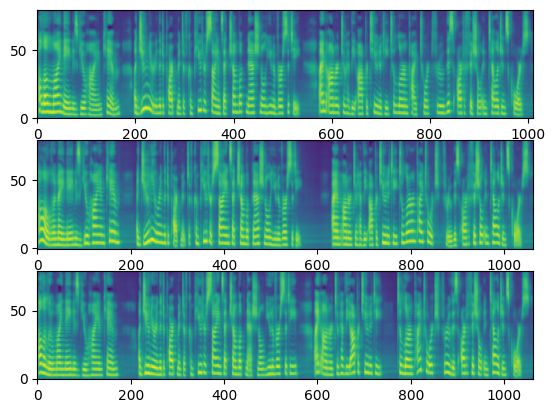

In [ ]:
def plot():
    fig, ax = plt.subplots(3, 1)
    for i in range(3):
        with torch.inference_mode():
            spec, spec_lengths, _ = tacotron2.infer(processed, lengths)
        print(spec[0].shape)
        ax[i].imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")


plot()

<br/>

## WaveRNN Vocoder

In [ ]:
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_PHONE_LJSPEECH

processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2().to(device)
vocoder = bundle.get_vocoder().to(device)

text = "Hello. My name is Gyu Hyeon Kim, a Junior in the Department of Computer Science at Chungbuk National University. I am honored to have the opportunity to learn PyTorch through this Artificial Intelligence course."

with torch.inference_mode():
    processed, lengths = processor(text)
    processed = processed.to(device)
    lengths = lengths.to(device)
    spec, spec_lengths, _ = tacotron2.infer(processed, lengths)
    waveforms, lengths = vocoder(spec, spec_lengths)

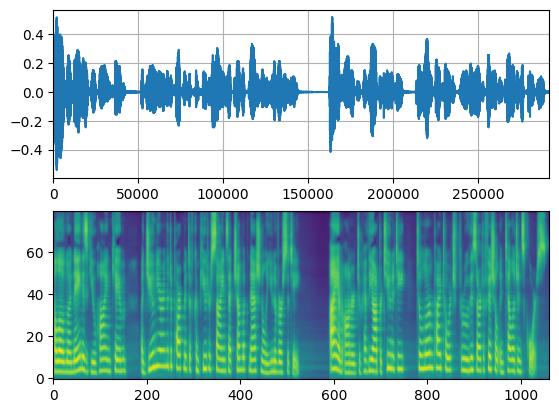

In [ ]:
def plot(waveforms, spec, sample_rate):
    waveforms = waveforms.cpu().detach()

    fig, [ax1, ax2] = plt.subplots(2, 1)
    ax1.plot(waveforms[0])
    ax1.set_xlim(0, waveforms.size(-1))
    ax1.grid(True)
    ax2.imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")
    return IPython.display.Audio(waveforms[0:1], rate=sample_rate)


plot(waveforms, spec, vocoder.sample_rate)

<br/>

## Griffin-Lim Vocoder

In [ ]:
bundle = torchaudio.pipelines.TACOTRON2_GRIFFINLIM_PHONE_LJSPEECH

processor = bundle.get_text_processor()
tacotron2 = bundle.get_tacotron2().to(device)
vocoder = bundle.get_vocoder().to(device)

with torch.inference_mode():
    processed, lengths = processor(text)
    processed = processed.to(device)
    lengths = lengths.to(device)
    spec, spec_lengths, _ = tacotron2.infer(processed, lengths)
waveforms, lengths = vocoder(spec, spec_lengths)

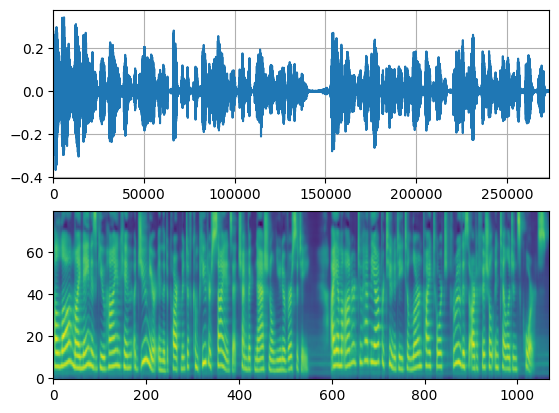

In [ ]:
plot(waveforms, spec, vocoder.sample_rate)

<br/>

## Waveglow Vocoder

In [ ]:
waveglow = torch.hub.load(
    "NVIDIA/DeepLearningExamples:torchhub",
    "nvidia_waveglow",
    model_math="fp32",
    pretrained=False,
)
checkpoint = torch.hub.load_state_dict_from_url(
    "https://api.ngc.nvidia.com/v2/models/nvidia/waveglowpyt_fp32/versions/1/files/nvidia_waveglowpyt_fp32_20190306.pth",
    progress=False,
    map_location=device,
)
state_dict = {key.replace("module.", ""): value for key, value in checkpoint["state_dict"].items()}

waveglow.load_state_dict(state_dict)
waveglow = waveglow.remove_weightnorm(waveglow)
waveglow = waveglow.to(device)
waveglow.eval()

with torch.no_grad():
    waveforms = waveglow.infer(spec)

Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub


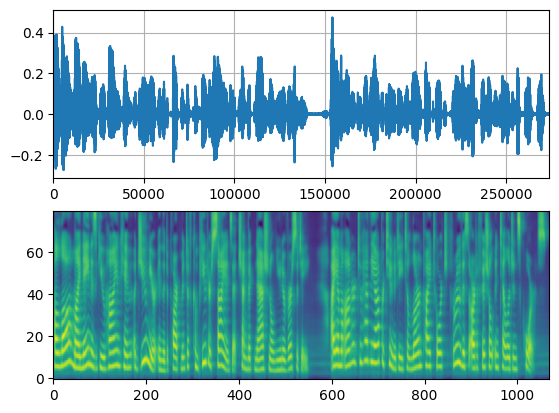

In [ ]:
plot(waveforms, spec, 22050)